# **SPAM DETECTION CLASSIFICATION**
HEheheHEHE

**Setting Environment**

In [ ]:
# Import library yang diperlukan
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer

**Load Dataset**

In [ ]:
#Load Dataset
df = pd.read_csv('/content/sms_spam_collection.csv', encoding='latin-1')

#Menampilkan 10 baris pertama
print("Dataset SMS Spam Collection: ")
display(df.head(10))

Dataset SMS Spam Collection: 


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [ ]:
print("\Informasi Dataset:")
df.info()

\Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
/tmp/ipykernel_2003/459626609.py:1: SyntaxWarning: invalid escape sequence '\I'
  print("\Informasi Dataset:")


In [ ]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


**Preprocessing Dataset**

In [ ]:
# Hapus kolom yang tidak relevan (kolom ini sudah tidak ada berdasarkan df.info())
# df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

# Ganti nama kolom 'message' menjadi 'text'
df.rename(columns={'message': 'text'}, inplace=True)

# Membersihkan kolom 'label' dari spasi ekstra dan mengubahnya ke huruf kecil
df['label'] = df['label'].str.strip().str.lower()

# Konversi label 'ham'/'spam' menjadi 0/1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print("Dataset setelah pembersihan:")
display(df.head())

print("\nDistribusi Label:")
display(df['label'].value_counts())

Dataset setelah pembersihan:


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."



Distribusi Label:


,count
label,
0,4825
1,747


In [ ]:
# Inisialisasi CountVectorizer
vectorizer = CountVectorizer()

# Ubah teks menjadi matriks jumlah token
X_transformed = vectorizer.fit_transform(df['text'])
y = df['label']

print(f"Bentuk data fitur setelah vectorization: {X_transformed.shape}")
print(f"Bentuk data target: {y.shape}")

# Tampilkan beberapa fitur pertama (kata-kata)
print("\nContoh 10 fitur pertama (kata-kata teratas):")
print(vectorizer.get_feature_names_out()[:10])

Bentuk data fitur setelah vectorization: (5572, 8749)
Bentuk data target: (5572,)

Contoh 10 fitur pertama (kata-kata teratas):
['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '0125698789' '02']


In [ ]:
# Mengganti X dan y dengan data yang sudah di-vectorize
X = X_transformed
# y sudah di definisikan di cell sebelumnya

print("Fitur (X) sudah di-vectorize.")
print("Target (y) sudah dikonversi ke numerik.")

Fitur (X) sudah di-vectorize.
Target (y) sudah dikonversi ke numerik.


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran data latih: {X_train.shape[0]} sampel")
print(f"Ukuran data uji: {X_test.shape[0]} sampel")

# Mengidentifikasi baris di y_train yang bukan NaN
non_nan_mask_train = ~y_train.isna()

# Filter X_train dan y_train untuk hanya menyertakan data yang valid
# Perbaikan: Tambahkan .values pada non_nan_mask_train saat mengindeks X_train
X_train_cleaned = X_train[non_nan_mask_train.values]
y_train_cleaned = y_train[non_nan_mask_train]

# Mengganti model Naive Bayes menjadi MultinomialNB yang lebih cocok untuk data hitungan (teks)
model = MultinomialNB()

# Latih model menggunakan data latih yang sudah di-vectorize dan telah dibersihkan
model.fit(X_train_cleaned, y_train_cleaned)

print("Model Multinomial Naive Bayes berhasil dilatih.")
print(f"Jumlah sampel data latih setelah pembersihan NaN: {X_train_cleaned.shape[0]} sampel")

Ukuran data latih: 4457 sampel
Ukuran data uji: 1115 sampel
Model Multinomial Naive Bayes berhasil dilatih.
Jumlah sampel data latih setelah pembersihan NaN: 4457 sampel


**Membuat Prediksi dan Evaluasi Model**

In [ ]:
# Membuat prediksi pada set pengujian
y_pred = model.predict(X_test)

print("Prediksi berhasil dibuat.")

Prediksi berhasil dibuat.


**Evaluasi Kinerja Model**

Akurasi Model: 0.9857

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.94      0.95      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



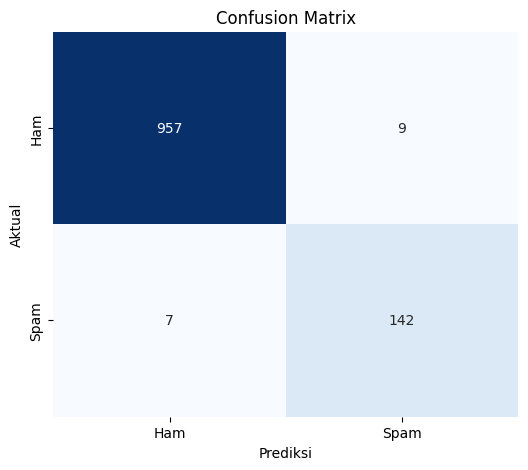

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Menghitung akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy:.4f}")

# Menampilkan report
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

# Menampilkan confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

#### Penjelasan Confusion Matrix

**Confusion Matrix** adalah tabel yang digunakan untuk menggambarkan kinerja model klasifikasi pada set data yang memiliki nilai kebenaran yang diketahui (label aktual). Ini membantu kita memahami di mana model membuat kesalahan dan jenis kesalahan apa yang dibuatnya.

Dari *Confusion Matrix* yang dihasilkan:

```
[[957,   9],
 [  7, 142]]
```

Penjelasannya adalah sebagai berikut:

*   **True Negatives (TN) = 957**: Ini adalah jumlah SMS yang **sebenarnya bukan spam (Ham)** dan **diprediksi dengan benar sebagai Ham**. Model Anda sangat baik dalam mengidentifikasi SMS yang bukan spam.

*   **False Positives (FP) = 9**: Ini adalah jumlah SMS yang **sebenarnya bukan spam (Ham)** tetapi **diprediksi salah sebagai Spam**. Ini juga dikenal sebagai **Type I error**. Dalam konteks ini, berarti 9 SMS yang sebenarnya tidak berbahaya malah ditandai sebagai spam.

*   **False Negatives (FN) = 7**: Ini adalah jumlah SMS yang **sebenarnya spam** tetapi **diprediksi salah sebagai Ham**. Ini juga dikenal sebagai **Type II error**. Ini adalah jenis kesalahan yang lebih serius dalam deteksi spam, karena berarti 7 SMS spam berhasil lolos dari filter dan mungkin sampai ke pengguna.

*   **True Positives (TP) = 142**: Ini adalah jumlah SMS yang **sebenarnya spam** dan **diprediksi dengan benar sebagai Spam**. Model Anda cukup baik dalam menangkap pesan spam.

**Kesimpulan dari Confusion Matrix:**
Model telah menunjukkan kinerja yang sangat baik secara keseluruhan. Model ini memiliki akurasi tinggi dalam mengklasifikasikan SMS yang bukan spam (Ham) dan juga cukup baik dalam mendeteksi spam. Namun, ada sedikit kesalahan, terutama 7 kasus spam yang tidak terdeteksi (False Negatives), yang mungkin perlu menjadi perhatian jika tujuan utamanya adalah memastikan tidak ada spam yang lolos sama sekali.